# Visualisation Z-Stacks

- example code for the visaulisation of Z-stacks
- use recording data from Jonathan Oesterle (OBM, 19.02.2025)
- code can be used later during the experiment to automatically visualise the IPL for identifying the plane of interest for recording
- as a note Jonathan used 0.43 µm to record the Z-stacks here
    - as for me I will be using my normal Zoom of 0.65 for recording the Z-stacks

## Load example data

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import os
import pickle
import re
import stackview as sv

from djimaging.utils.scanm import read_smp_utils

In [2]:
# Define folder path
image_folder = "/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/zstacks/20251209/"

In [4]:
# Generate file list from it
file_list = os.listdir(image_folder)

# Sort file list by XY#
#file_list = sorted(file_list, key=lambda x: int(re.search(r"XY(\d+)", x).group(1)))
file_list

['M1_LR_GCL2_UVG6rep_n1_control.smh', 'M1_LR_GCL2_UVG6rep_n1_control.smp']

In [5]:
# Filter file list for Z-stack images
file_list = [f for f in file_list
             if "zstack" in f and f.endswith(".smp")]
print(file_list)
print(file_list[-1])

[]


IndexError: list index out of range

In [7]:
# Load latest image from the file list
image = read_smp_utils.load_all_stacks_and_wparams(image_folder + 'M1_LR_GCL2_UVG6rep_n1_control.smp')
image

({'wDataCh0': array([[[10949, 10931, 10931, ..., 10949, 10931, 10949],
          [10949, 10940, 10949, ..., 10931, 10940, 10949],
          [10922, 10922, 10949, ..., 10940, 10931, 10931],
          ...,
          [10940, 10922, 10931, ..., 10931, 10931, 10949],
          [10922, 10940, 10931, ..., 10940, 10922, 10958],
          [10931, 10931, 10922, ..., 10940, 10922, 10922]],
  
         [[10949, 10949, 10958, ..., 10949, 10958, 10949],
          [10922, 10949, 10949, ..., 10958, 10949, 10958],
          [10949, 10958, 10949, ..., 10958, 10958, 10958],
          ...,
          [10949, 10940, 10949, ..., 10940, 10940, 10931],
          [10922, 10931, 10931, ..., 10940, 10949, 10940],
          [10922, 10931, 10949, ..., 10949, 10949, 10940]],
  
         [[10931, 11064, 11091, ..., 11082, 11118, 11100],
          [10940, 11091, 11091, ..., 11118, 11118, 11109],
          [10940, 11073, 11064, ..., 11109, 11109, 11118],
          ...,
          [10940, 10949, 10949, ..., 10940, 10940,

In [8]:
image[0]["wDataCh0"].shape

(512, 512, 10)

In [ ]:
sv.imshow(image[0]

In [18]:
# Fetsch the distance between the stacks from the metadata
z_step_um = image[1]["zstep_um"]
print(f"Z-steps in microns: {z_step_um}")

Z-steps in microns: 1.0


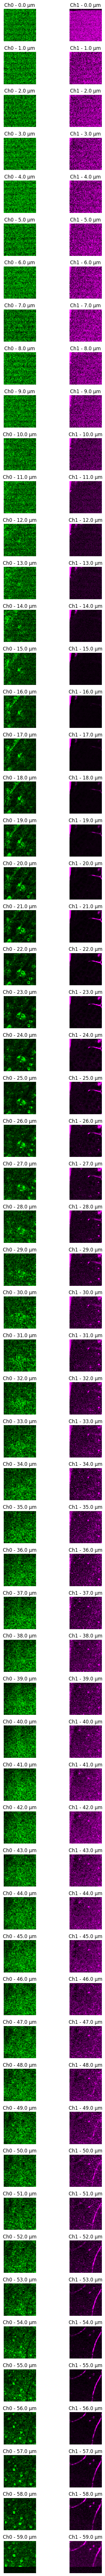

In [19]:
import matplotlib.pyplot as plt

# Fetch the number of slices
num_slices = image[0]["wDataCh1"].shape[2]

# Create a figure with 2 columns (one for each channel)
fig, axs = plt.subplots(num_slices, 2, figsize=(6, num_slices * 1.5))

# If only one slice, axs won’t be 2D, so ensure consistent shape
if num_slices == 1:
    axs = axs.reshape(1, 2)

# Loop through all z-slices
for i in range(num_slices):

    p05_channel_0 = np.percentile(image[0]["wDataCh0"][2:128, 2:128, i], 1)
    p95_channel_0 = np.percentile(image[0]["wDataCh0"][2:128, 2:128, i], 99)

    p05_channel_1 = np.percentile(image[0]["wDataCh1"][2:128, 2:128, i], 1)
    p95_channel_1 = np.percentile(image[0]["wDataCh1"][2:128, 2:128, i], 99)
    
    # Channel 0
    sv.imshow(
        image[0]["wDataCh0"][2:128, 2:128, i].T,
        plot=axs[i, 0],
        min_display_intensity=p05_channel_0,
        max_display_intensity=p95_channel_0,
        colormap="pure_green"
    )
    axs[i, 0].set_title(f"Ch0 - {i * z_step_um} µm")
    
    # Channel 1
    sv.imshow(
        image[0]["wDataCh1"][2:128, 2:128, i].T,
        plot=axs[i, 1],
        min_display_intensity=p05_channel_1,
        max_display_intensity=p95_channel_1,
        colormap="pure_magenta"
    )
    axs[i, 1].set_title(f"Ch1 - {i * z_step_um} µm")

plt.subplots_adjust(wspace=0.1)

plt.tight_layout()
plt.show()

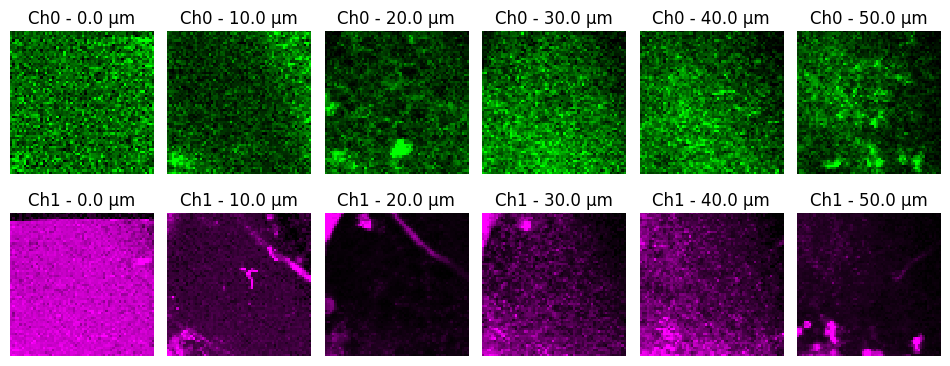

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Fetch total number of slices
num_slices = image[0]["wDataCh1"].shape[2]

# Select every 10th slice
slice_indices = range(0, num_slices, 10)
num_shown_slices = len(slice_indices)

# Create figure with 2 rows (one per channel) and as many columns as shown slices
fig, axs = plt.subplots(2, num_shown_slices, figsize=(num_shown_slices * 2, 4.5))

# Ensure axs is always 2D
if num_shown_slices == 1:
    axs = axs.reshape(2, 1)

for col_idx, i in enumerate(slice_indices):

    # Compute intensity percentiles for each channel
    p05_channel_0 = np.percentile(image[0]["wDataCh0"][2:128, 2:128, i], 1)
    p95_channel_0 = np.percentile(image[0]["wDataCh0"][2:128, 2:128, i], 99)

    p05_channel_1 = np.percentile(image[0]["wDataCh1"][2:128, 2:128, i], 1)
    p95_channel_1 = np.percentile(image[0]["wDataCh1"][2:128, 2:128, i], 99)

    # Channel 0 (top row)
    sv.imshow(
        image[0]["wDataCh0"][2:128, 2:128, i].T,
        plot=axs[0, col_idx],
        min_display_intensity=p05_channel_0,
        max_display_intensity=p95_channel_0,
        colormap="pure_green"
    )
    axs[0, col_idx].set_title(f"Ch0 - {i * z_step_um} µm")

    # Channel 1 (bottom row)
    sv.imshow(
        image[0]["wDataCh1"][2:128, 2:128, i].T,
        plot=axs[1, col_idx],
        min_display_intensity=p05_channel_1,
        max_display_intensity=p95_channel_1,
        colormap="pure_magenta"
    )
    axs[1, col_idx].set_title(f"Ch1 - {i * z_step_um} µm")

# Adjust layout
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.savefig("../images/20250908/M1_RR_t_XY3_zstack_xyimages_10microns-distance.png",
            dpi=300,
            bbox_inches="tight")

# Visualise Z-stack at specific slice

In [15]:
# Chose Z-depth for recording
picked_z_slice = 45

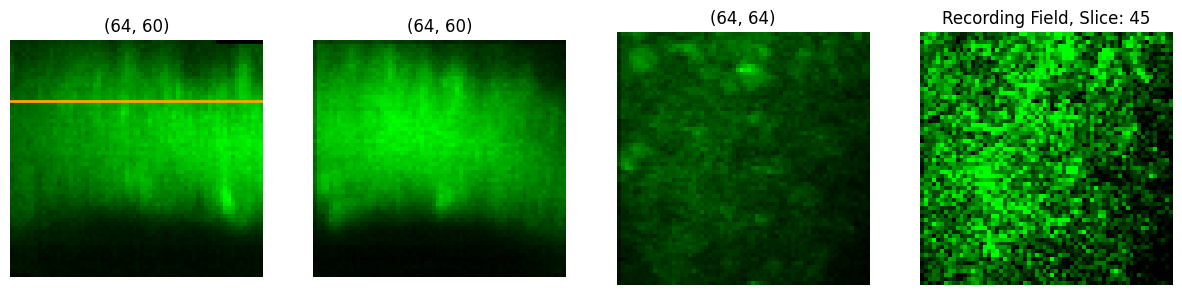

In [16]:
fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i in range(3):

    mean_image = np.mean(image[0]["wDataCh0"], axis = i)

    rotated_image = np.rot90(mean_image, k=1)
    
    sv.imshow(
        rotated_image,
        plot=axs[i],
        colormap="pure_green")

    axs[i].set_title(f"{np.mean(image[0]["wDataCh0"], axis = i).shape}")

sv.imshow(
    np.rot90(image[0]["wDataCh0"][..., picked_z_slice], k=1),
    plot=axs[3],
    colormap="pure_green",
    min_display_intensity=np.percentile(image[0]["wDataCh0"][..., picked_z_slice], 5),
    max_display_intensity=np.percentile(image[0]["wDataCh0"][..., picked_z_slice], 95))

axs[3].set_title(f"Recording Field, Slice: {picked_z_slice}")

line_y = 60 - picked_z_slice
axs[0].axhline(y=line_y, color="orange", linewidth=2)

In [17]:
image[0]["wDataCh0"].shape

(64, 64, 60)

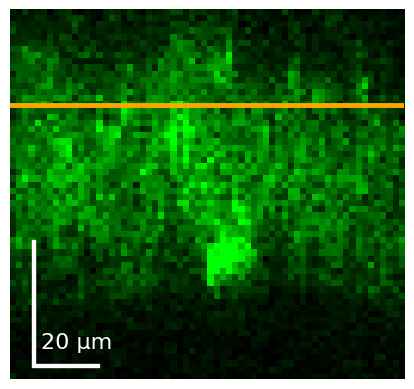

In [38]:
fig, axs = plt.subplots(1,1)

#mean_image = np.mean(image[0]["wDataCh0"], axis = 0)

#x_z = image_3d[..., y, :image_3d.shape[2]]

x_z_image = image[0]["wDataCh0"][..., 51, ::]

rotated_image = np.rot90(x_z_image, k=1)
    
sv.imshow(
    rotated_image,
    plot=axs,
    colormap="pure_green",
    min_display_intensity=np.percentile(rotated_image, 1),
    max_display_intensity=np.percentile(rotated_image, 99))

line_y = 60 - picked_z_slice
axs.axhline(y=line_y, color="orange", linewidth=3.5)

um_per_px_x = 1.71875   # horizontal
um_per_px_y = 1.0       # vertical

scale_um = 20  # µm

scale_px_x = int(scale_um / um_per_px_x)  # ~6 pixels
scale_px_y = int(scale_um / um_per_px_y)  # 10 pixels

# Place scale bars in bottom-left corner
x0, y0 = 3, 60-(scale_um+3)  # offset from corner in pixels

# Horizontal scale bar
axs.add_patch(
    patches.Rectangle((x0, y0 + scale_um), scale_px_x, 0.5, color="white")
)

# Vertical scale bar
axs.add_patch(
    patches.Rectangle((x0, y0), 0.5, scale_px_y, color="white")
)

axs.text(x0 + scale_px_x/1.5, y0 + (scale_um-5), "20 µm",
         color="white", ha="center", va="top", fontsize=16)

#plt.title("IPL reconstructed from Z-stack", fontsize=20)

plt.savefig("../images/20250908/M1_RR_t_XY3_zstack_XZimage_poster.png",
            dpi=300,
            bbox_inches="tight")

# Load Recording field for comparison

In [32]:
# Define folder to load and save files
image_data_recording = "/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250908/2/Raw/"

In [33]:
file_list_recording = os.listdir(image_data_recording)
file_list_recording = [filename for filename in file_list_recording
                       if "XY3_chirp" in filename and filename.endswith(".smp")]
file_list_recording

['M1_RR_t_XY3_chirp_C2.smp', 'M1_RR_t_XY3_chirp_C1.smp']

In [34]:
recording_field = read_smp_utils.load_all_stacks_and_wparams(image_data_recording + 'M1_RR_t_XY3_chirp_C1.smp')

In [41]:
recording_field[0]["wDataCh0"].shape

(64, 64, 1483)

In [43]:
np.array_equal(recording_field[0]["wDataCh0"], recording_field[0]["wDataCh1"])

False

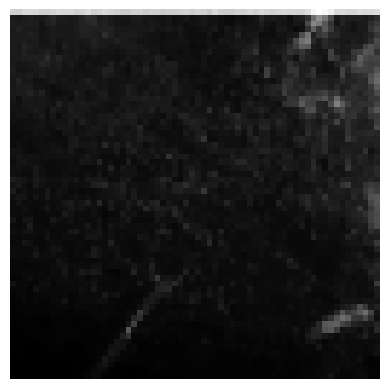

In [48]:
sv.imshow(np.mean(recording_field[0]["wDataCh1"], axis=2))

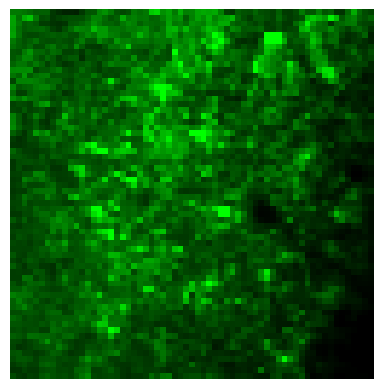

In [36]:
fig, axs = plt.subplots(1,1)

mean_image = np.mean(recording_field[0]["wDataCh0"], axis=2)

rotated_image = np.rot90(mean_image, k=1)

sv.imshow(
    rotated_image[:, 1:],
    colormap="pure_green",
    plot=axs,
    min_display_intensity=np.percentile(rotated_image[:, 8:], 1),
    max_display_intensity=np.percentile(rotated_image[:, 8:], 99))

#plt.title("XY recording field", fontsize=20)

plt.savefig("../images/20250908/M1_RR_t_XY3_chirp_C1_poster.png",
            dpi=300,
            bbox_inches="tight")

#axs[i].set_title(f"{np.mean(image[0]["wDataCh0"], axis = i).shape}")

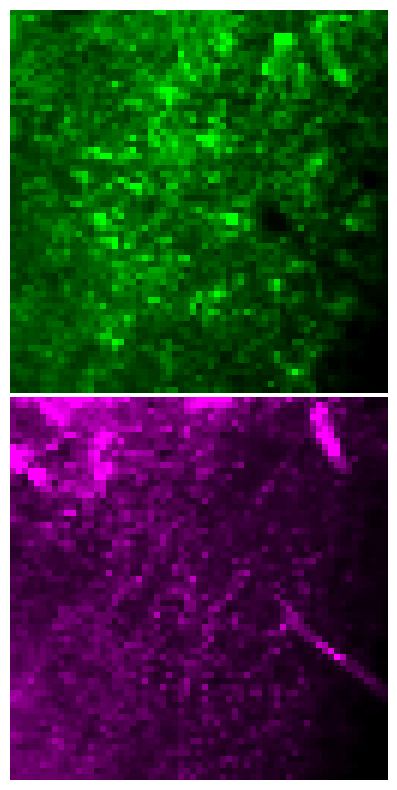

In [52]:
fig, axs = plt.subplots(2, 1, figsize=(10,10))

mean_image_ch0 = np.mean(recording_field[0]["wDataCh0"], axis=2)

rotated_image_ch0 = np.rot90(mean_image, k=1)

sv.imshow(
    rotated_image_ch0[:, 1:],
    colormap="pure_green",
    plot=axs[0],
    min_display_intensity=np.percentile(rotated_image_ch0[:, 8:], 1),
    max_display_intensity=np.percentile(rotated_image_ch0[:, 8:], 99))

mean_image_ch1 = np.mean(recording_field[0]["wDataCh1"], axis=2)

rotated_image_ch1 = np.rot90(mean_image_ch1, k=1)

sv.imshow(
    rotated_image_ch1[:, 1:],
    colormap="pure_magenta",
    plot=axs[1],
    min_display_intensity=np.percentile(rotated_image_ch1[:, 8:], 1),
    max_display_intensity=np.percentile(rotated_image_ch1[:, 8:], 99))

plt.subplots_adjust(hspace=0.01)

#plt.title("XY recording field", fontsize=20)

plt.savefig("../images/20250908/M1_RR_t_XY3_chirp_ch0_ch1_recording_field.png",
            dpi=300,
            bbox_inches="tight")

#axs[i].set_title(f"{np.mean(image[0]["wDataCh0"], axis = i).shape}")

Text(0.5, 1.0, 'Recording Field, Slice: 45')

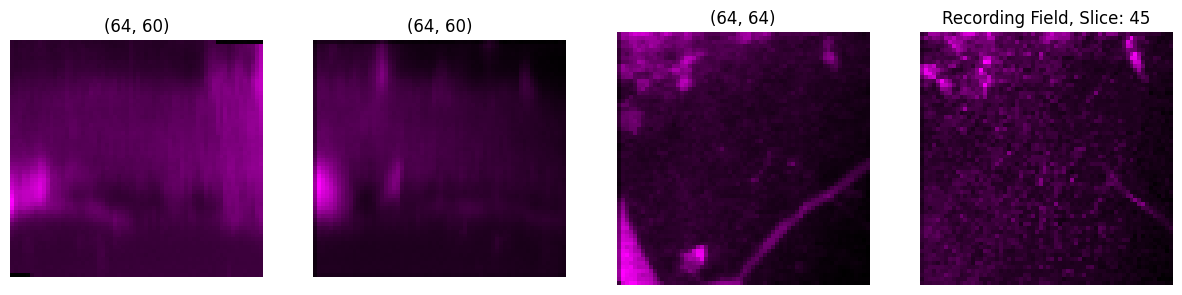

In [24]:
fig, axs = plt.subplots(1, 4, figsize=(15, 15))

for i in range(3):

    mean_image = np.mean(image[0]["wDataCh1"], axis = i)

    rotated_image = np.rot90(mean_image, k=1)
    
    sv.imshow(
        rotated_image,
        plot=axs[i],
        colormap="pure_magenta")

    axs[i].set_title(f"{np.mean(image[0]["wDataCh1"], axis = i).shape}")

sv.imshow(
    np.rot90(image[0]["wDataCh1"][..., picked_z_slice], k=1),
    plot=axs[3],
    colormap="pure_magenta")

axs[3].set_title(f"Recording Field, Slice: {picked_z_slice}")

### Visualise ROIs

In [2]:
# Define folder to load and save files
roi_data = "/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20250908/2/ROIs/"

In [3]:
# Define a file list
file_list_roi = os.listdir(roi_data)
file_list_roi

['M1_RR_n_XY7_mb_C1_ROIs.pkl',
 'M1_RR_n_XY8_mb_DETANO_ROIs.pkl',
 'M1_RR_t_XY4_mb_DETANO_ROIs.pkl',
 'M1_RR_v_XY1_mb_C2_ROIs.pkl',
 'M1_RR_d_XY6_mb_C1_ROIs.pkl',
 'M1_RR_t_XY3_mb_C1_ROIs.pkl',
 'M1_RR_t_XY3_mb_C2_ROIs.pkl',
 'M1_RR_d_XY5_mb_C1_ROIs.pkl',
 'M1_RR_n_XY8_lchirp_DETANO_ROIs.pkl',
 'M1_RR_v_XY1_chirp_C2_ROIs.pkl',
 'M1_RR_v_XY2_mb_DETANO_ROIs.pkl',
 'M1_RR_n_XY7_chirp_C2_ROIs.pkl',
 'M1_RR_v_XY1_mb_C1_ROIs.pkl',
 'M1_RR_v_XY2_chirp_DETANO_ROIs.pkl',
 'M1_RR_d_XY6_lchirp_C1_ROIs.pkl',
 'M1_RR_d_XY5_lchirp_C2_ROIs.pkl',
 'M1_RR_d_XY5_lchirp_C1_ROIs.pkl',
 'M1_RR_v_XY2_lchirp_DETANO_ROIs.pkl',
 'M1_RR_t_XY3_lchirp_C1_ROIs.pkl',
 'M1_RR_v_XY1_lchirp_C1_ROIs.pkl',
 'M1_RR_v_XY2_lchirp_C1_ROIs.pkl',
 'M1_RR_t_XY3_chirp_C1_ROIs.pkl',
 'M1_RR_v_XY2_chirp_C1_ROIs.pkl',
 'M1_RR_d_XY5_mb_C2_ROIs.pkl',
 'M1_RR_n_XY8_mb_C1_ROIs.pkl',
 'M1_RR_t_XY4_chirp_DETANO_ROIs.pkl',
 'M1_RR_n_XY7_chirp_C1_ROIs.pkl',
 'M1_RR_d_XY6_chirp_C1_ROIs.pkl',
 'M1_RR_d_XY5_chirp_C1_ROIs.pkl',
 'M1_RR_n_XY8_

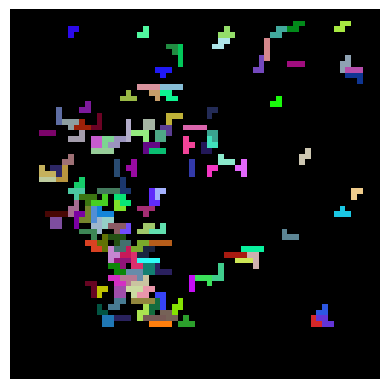

In [4]:
with open(roi_data + 'M1_RR_t_XY3_chirp_C1_ROIs.pkl', "rb") as f:
    rois = pickle.load(f)

rois = np.rot90(rois, k=1)

sv.imshow(rois, labels=True)

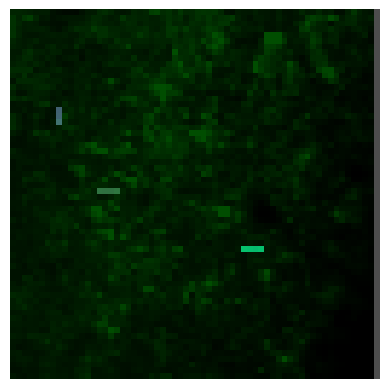

In [30]:
# List of ROIs to visualize
selected_rois = [45, 73, 109]

# Create a mask that only keeps the selected ROIs
filtered_mask = np.isin(rois, selected_rois) * rois

sv.imshow(
    rotated_image[:, 1:],
    colormap="pure_green",
    min_display_intensity=np.percentile(rotated_image[:, 8:], 1),
    max_display_intensity=np.percentile(rotated_image[:, 8:], 99),
    continue_drawing=True)

sv.imshow(filtered_mask, labels=True, alpha=0.7)

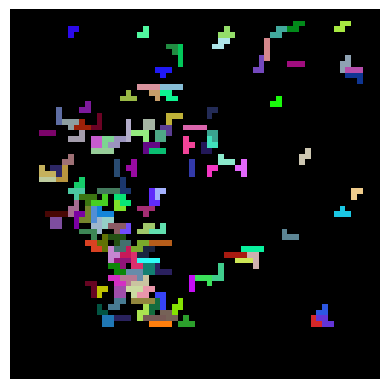

In [36]:
fig, axs = plt.subplots(1,1)

sv.imshow(rois, labels=True, plot=axs)

#plt.title("Automatically generated ROIs", fontsize=20)

plt.savefig("../images/20250908/M1_RR_t_XY3_chirp_ROIs_poster.png",
            dpi=300,
            bbox_inches="tight")

In [46]:
for i, roi_mask in enumerate(rois):
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63


# Alles zusammen matschen (wie Frankenstein's Monster)

### Orthogonal view

- visualise 3D image with orthogonal view from a respective Z of (x, y, z) coordinates
- function taken from Quapos paper (Suse und Flo)

In [98]:
import matplotlib.pyplot as plt
import numpy as np
import stackview as sv
from matplotlib.colors import ListedColormap


def orthogonal_view(image1,
                    x_coordinate,
                    y_coordinate,
                    z_coordinate,
                    image2=None,
                    scale_bar_length=25,
                    scale_colour="white",
                    micron_length=0.323,
                    dot_size=1,
                    dot_colour="orange",
                    save_path=None,
                    labels=False):
    """
    Display orthogonal views of a 3D image with a dot at specified coordinates.
    If a second image is provided, show both images side by side for comparison.

    Parameters:
    - image1 (numpy.ndarray): First 3D array representing the image data.
    - x_coordinate, y_coordinate, z_coordinate (int): Coordinates for the dot.
    - image2 (numpy.ndarray or None): Optional second 3D image for comparison.
    - dot_size (int): Radius (in pixels) of the dot marker.
    - dot_colour (str): Color of the dot.
    """

    def make_dot(image_3d, x, y, z, size):
        # Compute planes
        x_y = image_3d[z, ...]
        y_z = image_3d[..., :image_3d.shape[1], x].T
        x_z = image_3d[..., y, :image_3d.shape[2]]

        # Dot overlays
        cross_xy = np.zeros_like(x_y)
        cross_xy[y-size:y+size+1, x-size:x+size+1] = 1

        cross_yz = np.zeros_like(y_z)
        cross_yz[y-size:y+size+1, z-size:z+size+1] = 1

        cross_xz = np.zeros_like(x_z)
        cross_xz[z-size:z+size+1, x-size:x+size+1] = 1

        return (x_y, y_z, x_z), (cross_xy, cross_yz, cross_xz)

    cmap_dot = ListedColormap(["none", dot_colour])

    if image2 is None:
        # --- Single image mode ---
        planes, dots = make_dot(image1, x_coordinate, y_coordinate, z_coordinate, dot_size)

        fig, axs = plt.subplots(2, 2, figsize=(8, 8))
        axs[1, 1].remove()

        # XY
        sv.imshow(planes[0], plot=axs[0, 0], labels=labels)
        sv.imshow(dots[0], plot=axs[0, 0], colormap=cmap_dot)

        # YZ
        sv.imshow(planes[1], plot=axs[0, 1], labels=labels)
        sv.imshow(dots[1], plot=axs[0, 1], colormap=cmap_dot)

        # XZ
        sv.imshow(planes[2], plot=axs[1, 0], labels=labels)
        sv.imshow(dots[2], plot=axs[1, 0], colormap=cmap_dot)

        for ax in [axs[0, 0], axs[0, 1], axs[1, 0]]:
            ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

        plt.subplots_adjust(wspace=-0.37, hspace=-0.37)
        axs[0, 0].set_title(f"X: {x_coordinate}, Y: {y_coordinate}, Z: {z_coordinate}")

    else:
        # --- Comparison mode with two images ---
        planes1, dots1 = make_dot(image1, x_coordinate, y_coordinate, z_coordinate, dot_size)
        planes2, dots2 = make_dot(image2, x_coordinate, y_coordinate, z_coordinate, dot_size)

        fig, axs = plt.subplots(2, 3, figsize=(12, 8))

        for row, (planes, dots) in enumerate([(planes1, dots1), (planes2, dots2)]):
            sv.imshow(planes[0], plot=axs[row, 0], labels=labels)
            sv.imshow(dots[0], plot=axs[row, 0], colormap=cmap_dot)
            axs[row, 0].set_title(["Image1 XY", "Image2 XY"][row])

            sv.imshow(planes[1], plot=axs[row, 1], labels=labels)
            sv.imshow(dots[1], plot=axs[row, 1], colormap=cmap_dot)
            axs[row, 1].set_title(["Image1 YZ", "Image2 YZ"][row])

            sv.imshow(planes[2], plot=axs[row, 2], labels=labels)
            sv.imshow(dots[2], plot=axs[row, 2], colormap=cmap_dot)
            axs[row, 2].set_title(["Image1 XZ", "Image2 XZ"][row])

            for ax in axs[row, :]:
                ax.tick_params(left=False, right=False, labelleft=False, labelbottom=False, bottom=False)

        plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Plot saved to {save_path}")
    else:
        plt.show()

In [99]:
# Reshape the dataframe, GCampf6
# Function requires the format in (z, x, y)
image_recording = np.transpose(image[0]["wDataCh0"], (2, 0, 1))
print(f"Old shape: {image[0]["wDataCh0"].shape}")
print(f"New shape: {image_recording.shape}")

Old shape: (64, 64, 71)
New shape: (71, 64, 64)


In [102]:
# Define coordinates
x, y, z, = 30, 32, 32

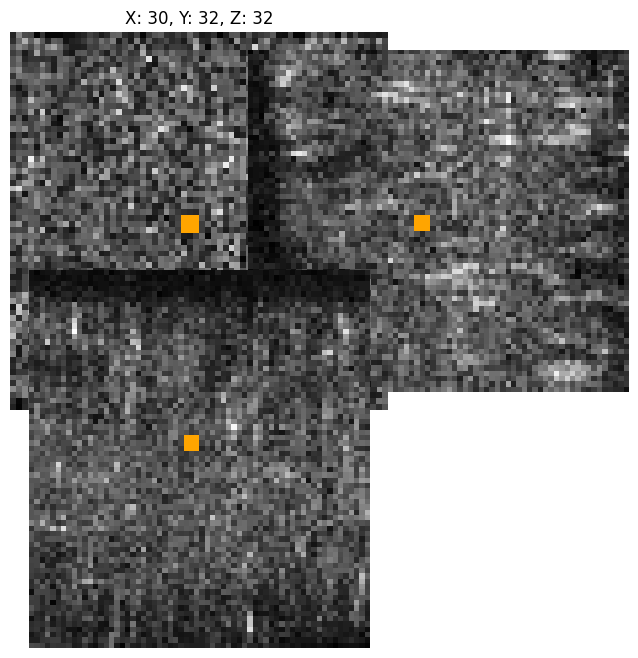

In [103]:
# Show the orthogonal view
orthogonal_view(
    image1=image_recording,
    x_coordinate=x,
    y_coordinate=y,
    z_coordinate=z)

In [105]:
# Reshape the dataframe, SR101
# Function requires the format in (z, x, y)
image_blood_vessels = np.transpose(image[0]["wDataCh1"], (2, 0, 1))
print(f"Old shape: {image[0]["wDataCh1"].shape}")
print(f"New shape: {image_blood_vessels.shape}")

Old shape: (64, 64, 71)
New shape: (71, 64, 64)


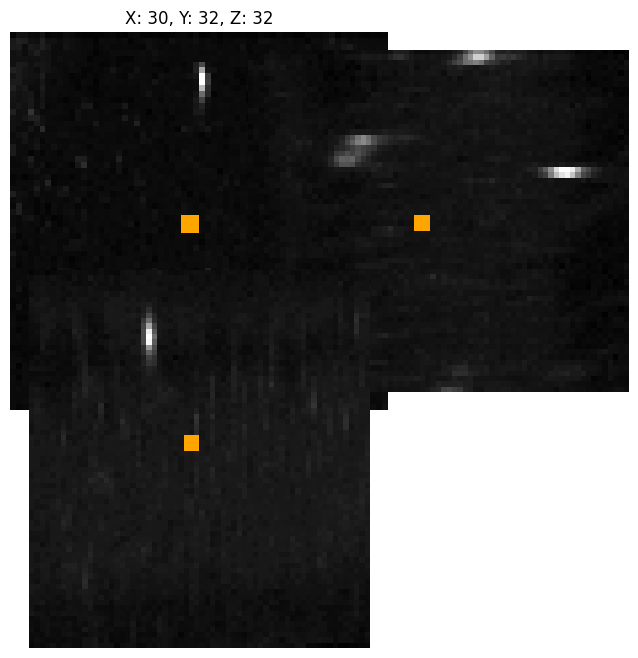

In [106]:
# Show the orthogonal view
orthogonal_view(
    image1=image_blood_vessels,
    x_coordinate=x,
    y_coordinate=y,
    z_coordinate=z)

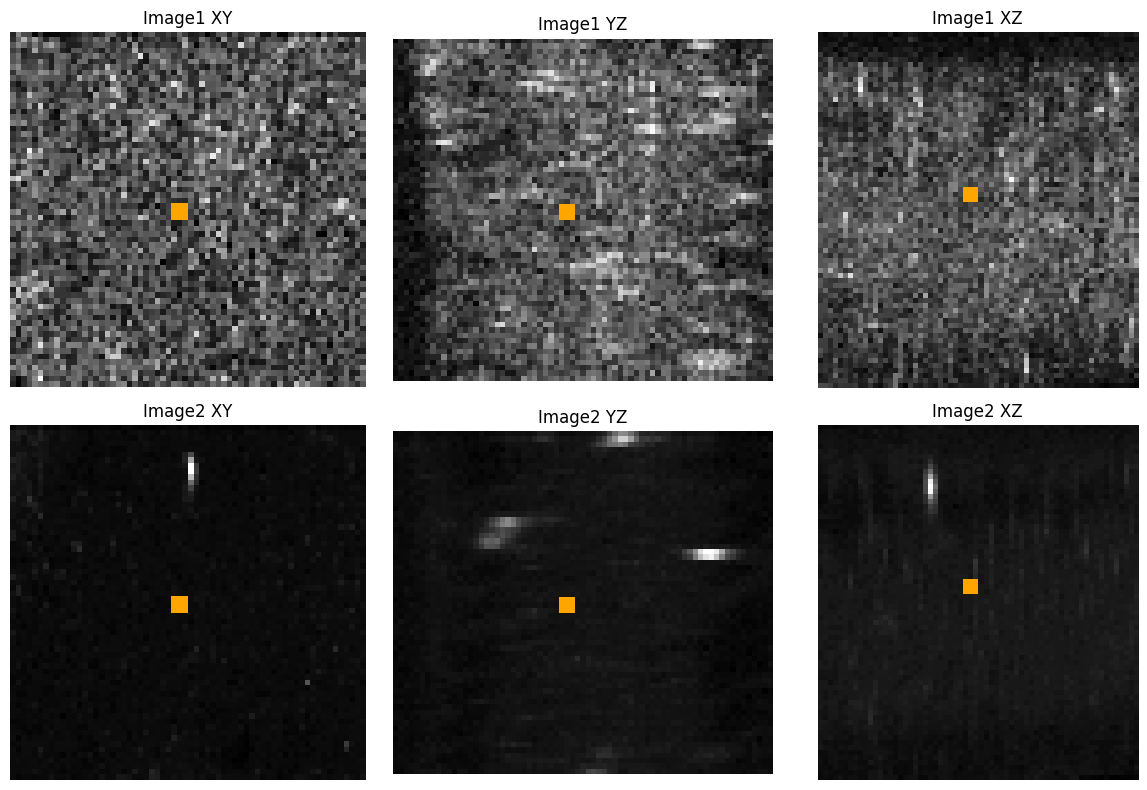

In [107]:
# Also possible to do with 2 images...
orthogonal_view(
    image1=image_recording,
    image2=image_blood_vessels,
    x_coordinate=x,
    y_coordinate=y,
    z_coordinate=z)